# Calculate Probabilistic Forecast Data (Cleaned)

**Date created:** September 3rd, 2025 

**Date edited:** October 21st, 2025

**Author:** Prakrut Kansara, edited by Kris Su

**Description:** This notebook calculates the `TERCILE CATEGORY PROBABILITY EXCEEDANCE` used for the heatmap figure in the AmazonHydroViewer webapp.

**Improvements in this version:**
- Proper soil profile level handling and saving
- Memory management with garbage collection
- Better path handling with pathlib
- Improved error handling and logging
- Removed duplicate function definitions
- Enhanced documentation
- Fixed `.items()` bug
- Proper soil profile level handling
- Memory management with garbage collection
- **NEW:** Extract river networks for each tercile category separately
- **NEW:** Save separate GeoJSON files for below-normal, normal, and above-normal categories
- Enhanced error handling and documentation

**Tercile Categories:**
- Category 0: Below normal (< 33rd percentile) - typically dry conditions
- Category 1: Normal (33rd-67th percentile) - typical conditions  
- Category 2: Above normal (> 67th percentile) - typically wet conditions

**Surface variable units:**
- `Rainf_tavg`: mm/day
- `Qair_f_tavg`: g/kg
- `Qs_tavg`: mm/day
- `Evap_tavg`: mm/day
- `Tair_f_tavg`: degree Celsius
- `SoilMoist_inst`: m³/m³ (by profile level)
- `SoilTemp_inst`: degree Celsius (by profile level)
- `Streamflow_tavg`: m³/s

In [3]:
import xarray as xr
import geopandas as gpd
import numpy as np
import re
import gc
from tqdm import tqdm
from pathlib import Path
from shapely.geometry import box
from backendcore import *
import pickle
import pandas as pd

## Functions

In [ ]:
# def read_trim_forecast(file_path, va):
#     """
#     Read forecast data for a specific variable.
    
#     Args:
#         file_path (str): Path to forecast NetCDF file
#         va (str): Variable name to extract

#     Returns:
#         xarray.DataArray: Forecast data for the variable
#     """
#     try:
#         forecast_data = xr.open_dataset(file_path)[va]
#         return forecast_data
#     except KeyError:
#         print(f'ERROR: Variable {va} not found in dataset {file_path}')
#         raise

In [ ]:
# def read_trim_hindcast(file_path, va):
#     """
#     Read hindcast data for a specific variable from multiple files.
    
#     Args:
#         file_path (str or list): Path(s) to hindcast NetCDF file(s)
#         va (str): Variable name to extract
        
#     Returns:
#         xarray.DataArray: Hindcast data for the variable, chunked by time
#     """
#     try:
#         hindcast_data = xr.open_mfdataset(file_path, join='outer')[va]
#         return hindcast_data
#     except KeyError:
#         print(f'ERROR: Variable {va} not found in hindcast dataset')
#         raise

In [ ]:
# def get_thresh(icat, quantiles, xrds, dims=['ensemble', 'time']):
#     """
#     Calculate threshold boundaries for a category based on quantiles.
    
#     Args:
#         icat (int): Category index (0, 1, 2 for terciles)
#         quantiles (list): Quantile boundaries (e.g., [1/3, 2/3] for terciles)
#         xrds (xarray.DataArray): Data array to calculate quantiles from
#         dims (list): Dimensions to calculate quantiles over
    
#     Returns:
#         tuple: (lower_threshold, upper_threshold) for the category
#     """
#     if not all(elem in xrds.dims for elem in dims): 
#         raise Exception(f'Some dimensions in {dims} not present in xr.DataArray {xrds.dims}')

#     if icat == 0:  # Below normal category
#         xrds_lo = -np.inf
#         xrds_hi = xrds.quantile(quantiles[icat], dim=dims)
#     elif icat == len(quantiles):  # Above normal category
#         xrds_lo = xrds.quantile(quantiles[icat-1], dim=dims) 
#         xrds_hi = np.inf
#     else:  # Normal category
#         xrds_lo = xrds.quantile(quantiles[icat-1], dim=dims)
#         xrds_hi = xrds.quantile(quantiles[icat], dim=dims)
    
#     return xrds_lo, xrds_hi

In [ ]:
# def calculate_probabilities(hcst, fcst, quantiles=[1/3., 2/3.]):
#     """
#     Calculate tercile category probability exceedance for ensemble forecast.
    
#     Uses hindcast to define climatological tercile boundaries (below-normal, 
#     normal, above-normal), then calculates probability that forecast ensemble
#     members fall into each category.
    
#     Args:
#         hcst (xarray.DataArray): Hindcast data with dims [time, ensemble, lat, lon]
#         fcst (xarray.DataArray): Forecast data with dims [time, ensemble, lat, lon]
#         quantiles (list): Category boundaries (default: terciles at [1/3, 2/3])
    
#     Returns:
#         xarray.DataArray: Probability (0-1) that forecast falls in each category
#                          Dims: [category, time, lat, lon]
#                          - Category 0 = below normal (< 33rd percentile)
#                          - Category 1 = normal (33rd-67th percentile)
#                          - Category 2 = above normal (> 67th percentile)
#     """
#     print('Computing probabilities...')
#     numcategories = len(quantiles) + 1  # 3 categories for terciles

#     # Mask out 0 values in forecast (assumes 0 = missing/invalid)
#     # NOTE: Verify this is appropriate for your data
#     fcst_masked = fcst.where(fcst != 0)

#     l_probs = []
#     for icat in range(numcategories):
#         print(f'  category={icat}')
#         h_lo, h_hi = get_thresh(icat, quantiles, hcst)
        
#         # Count fraction of ensemble members in this category
#         prob = np.logical_and(fcst_masked > h_lo, fcst_masked <= h_hi).sum('ensemble') / float(fcst_masked.sizes['ensemble'])
        
#         # Remove quantile coordinate if present (artifact from threshold calculation)
#         if 'quantile' in prob.coords:
#             prob = prob.drop_vars('quantile')
        
#         l_probs.append(prob.assign_coords({'category': icat}))
    
#     probs = xr.concat(l_probs, dim='category')
#     return probs

## River Network Extraction Functions

In [ ]:
# def as_2d(da, xdim="lon", ydim="lat"): 
#     """
#     Convert multi-dimensional data array to 2D spatial grid.
    
#     Drops size-1 dimensions and averages over non-spatial dimensions.
    
#     Args:
#         da (xarray.DataArray): Input data array
#         xdim (str): Longitude dimension name
#         ydim (str): Latitude dimension name
        
#     Returns:
#         xarray.DataArray: 2D array with dims (lat, lon)
#     """
#     # Drop size-1 dims
#     da = da.squeeze(drop=True)
#     # Reduce any leftover non-spatial dims (e.g., ensemble/step/time) to mean
#     reduce_dims = [d for d in da.dims if d not in (ydim, xdim)]
#     if reduce_dims:
#         da = da.mean(dim=reduce_dims, skipna=True)
#     # Ensure order is (lat, lon)
#     return da.transpose(ydim, xdim)

In [ ]:
# def extract_river_network_by_category(
#     streamflow_data, 
#     probability_data, 
#     flow_threshold=50.0,
#     time_index=0
# ):
#     """
#     Extract river network polygons for each tercile category separately.
    
#     Args:
#         streamflow_data (xr.DataArray): Hindcast streamflow data for threshold filtering
#         probability_data (xr.DataArray): Probability data with 'category' dimension
#         flow_threshold (float): Minimum probability to include cell in river network
#         time_index (int): Time index to select (default: 0 for first forecast month)
        
#     Returns:
#         dict: Dictionary with keys 'cat_0', 'cat_1', 'cat_2' containing GeoDataFrames
#     """    
#     # Get spatial coordinates
#     lon = streamflow_data["lon"].values
#     lat = streamflow_data["lat"].values
#     river_mask = streamflow_data.values
    
#     # Create mask for river cells (where streamflow >= threshold)
#     #river_mask = np.isfinite(flow_values) & (flow_values >= flow_threshold)
#     ii, jj = np.where(river_mask)
    
#     print(f"Found {len(ii)} river cells above threshold {flow_threshold} %")
    
#     # Extract each category
#     category_gdfs = {}
#     category_names = {
#         0: 'below_normal',
#         1: 'near_normal', 
#         2: 'above_normal'
#     }
    
#     for cat_idx in range(3):  # Three tercile categories
#         print(f"\nProcessing Category {cat_idx}: {category_names[cat_idx]}")
        
#         # Select this category's probability data
#         cat_probs = probability_data.sel(category=cat_idx).isel(time=time_index)
#         prob_2d = as_2d(cat_probs)
#         prob_values = prob_2d.values
        
#         # Build polygons only for river cells
#         geoms = []
#         attrs = []
        
#         for i, j in zip(ii, jj):
#             if i+1 < len(lat) and j+1 < len(lon):
#                 prob_val = prob_values[i, j]
                
#                 # Only include if probability is not NaN
#                 if np.isfinite(prob_val):
#                     # Create polygon for this grid cell
#                     geom = box(lon[j], lat[i+1], lon[j+1], lat[i])
#                     geoms.append(geom)
                    
#                     # Store attributes
#                     attrs.append({
#                         "streamflow": float(river_mask[i, j]),
#                         "probability": float(prob_val),
#                         "category": cat_idx,
#                         "category_name": category_names[cat_idx],
#                         "lat": float(lat[i]),
#                         "lon": float(lon[j])
#                     })
        
#         # Create GeoDataFrame
#         if geoms:
#             gdf = gpd.GeoDataFrame(attrs, geometry=geoms, crs="EPSG:4326")
#             category_gdfs[f'cat_{cat_idx}'] = gdf
#             print(f"  ✓ Extracted {len(gdf)} cells for category {cat_idx}")
#         else:
#             print(f"  ⚠ No cells found for category {cat_idx}")
#             category_gdfs[f'cat_{cat_idx}'] = gpd.GeoDataFrame()
    
#     return category_gdfs

In [ ]:
# def extract_river_network_all_time(
#     streamflow_data,
#     probability_data,
#     flow_threshold=50.0,
# ):
#     ntime = probability_data.sizes["time"]
#     results = {}

#     for t in range(ntime):
#         time_val = probability_data["time"].values[t]
#         time_val = str(time_val)[0:-22]
#         print(f"\n=== Time index {t + 1} ({time_val}) ===")

#         results[time_val] = extract_river_network_by_category(
#             streamflow_data=streamflow_data,
#             probability_data=probability_data,
#             flow_threshold=flow_threshold,
#             time_index=t,
#         )

#     return results

## Helper Functions for File Management

In [ ]:
# # Month name to number mapping
# _MONTHS = {m: i+1 for i, m in enumerate(
#     ["jan", "feb", "mar", 
#      "apr", "may", "jun", 
#      "jul", "aug", "sep", 
#      "oct", "nov", "dec"]
# )}

# # Filename patterns to recognize
# _PATTERNS = [
#     re.compile(r'^ldas_fcst_(\d{4})_([a-z]{3})(\d{2})\.nc$', re.I),  # ldas_fcst_2024_dec01.nc
#     re.compile(r'^ldas_fcst_(\d{4})(\d{2})(\d{2})\.nc$', re.I),      # ldas_fcst_20241201.nc
# ]

# def _parse_date_from_name(name: str) -> datetime | None:
#     """
#     Parse initialization date from forecast filename.
    
#     Supports formats:
#     - ldas_fcst_2024_dec01.nc
#     - ldas_fcst_20241201.nc
#     """
#     for pat in _PATTERNS:
#         m = pat.match(name)
#         if not m:
#             continue
#         if pat is _PATTERNS[0]:
#             y = int(m.group(1))
#             mon = _MONTHS.get(m.group(2).lower())
#             d = int(m.group(3))
#         else:
#             y, mon, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
#         if mon and 1 <= mon <= 12 and 1 <= d <= 31:
#             return datetime(y, mon, d)
#     return None

# def forecast_init_datetime(fpath: str) -> datetime:
#     """Extract initialization datetime from forecast file path."""
#     dt = _parse_date_from_name(Path(fpath).name)
#     if dt is None:
#         raise ValueError(f"Unrecognized forecast filename format: {fpath}")
#     return dt

In [ ]:
# def split_forecast_and_dec_hindcasts(
#     dir_path: str,
#     prefix: str = "ldas_fcst_",
#     recursive: bool = False
# ):
#     """
#     Find latest forecast file and all December 1st hindcast files.
    
#     Args:
#         dir_path (str): Directory containing forecast files
#         prefix (str): Filename prefix to match
#         recursive (bool): Search subdirectories
        
#     Returns:
#         tuple: (forecast_path, hindcast_paths_list, forecast_datetime)
#     """
#     base = Path(dir_path)
#     if not base.is_dir():
#         raise NotADirectoryError(f"Not a directory: {dir_path}")

#     pattern = "**/*.nc" if recursive else "*.nc"
#     items = []
#     for p in base.glob(pattern):
#         if not p.is_file():
#             continue
#         name = p.name
#         if not name.startswith(prefix) or not name.endswith(".nc"):
#             continue
#         dt = _parse_date_from_name(name)
#         if dt is None:
#             continue
#         items.append((dt, p.stat().st_mtime, name, p))

#     if not items:
#         raise FileNotFoundError(f"No matching .nc files found in {dir_path} (prefix='{prefix}')")

#     # Latest by (date, mtime, name)
#     items.sort(key=lambda t: (t[0], t[1], t[2]))
#     forecast_path = items[-1][3]
#     forecast_dt = items[-1][0]

#     # Hindcasts = existing Dec-01 files from earlier years only
#     hindcasts = [
#         p for (dt, _, _, p) in items
#         if dt.year < forecast_dt.year and dt.month == 12 and dt.day == 1
#     ]
#     # Sort hindcasts by year ascending (oldest → newest)
#     hindcasts.sort(key=lambda p: _parse_date_from_name(p.name))

#     return str(forecast_path), [str(p) for p in hindcasts], forecast_dt

## Configuration & File Discovery

In [4]:
# Variable definitions
list_of_variables = {
    'Rainf_tavg': 'Average precipitation', 
    'Qair_f_tavg': 'Specific humidity',
    'Qs_tavg': 'Surface runoff',
    'Evap_tavg': 'Evapotranspiration',
    'Tair_f_tavg': 'Avg. air temperature',
    'SoilMoist_inst': 'Soil moisture',
    'SoilTemp_inst': 'Soil temperature',
    'Streamflow_tavg': 'Stream flow'
}

# Data directory
surface_model_file_path = r"/mnt/vast/prakrut/backup/malaria_amazon/amazon_forecast"

# Find forecast and hindcast files
try: 
    forecast_file, hindcast_files, f_dt = split_forecast_and_dec_hindcasts(surface_model_file_path)
    print("Forecast file:", forecast_file)
    print("Hindcasts   :", len(hindcast_files), "files")
    print("Init date   :", f_dt)
    # Create initialization date tag
    initialization_date = f"{f_dt.year}_{f_dt.strftime('%b').lower()}"
    print("Forecast initialization date:", initialization_date)

except Exception as e:
    print(f"{type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


# Create output directories
output_dir = Path('../get_ldas_probabilistic_output')
output_dir.mkdir(exist_ok=True, parents=True)

# Create output directories for nc files
output_dir_cache = Path('../get_ldas_probabilistic_output/tmp')
output_dir_cache.mkdir(exist_ok=True, parents=True)

geojson_output_dir = output_dir / 'geojson'
geojson_output_dir.mkdir(exist_ok=True, parents=True)

for var in list_of_variables.keys():
    geojson_output_dir_per_var = geojson_output_dir / var
    geojson_output_dir_per_var.mkdir(exist_ok=True, parents=True)

print(f"\nOutput directory: {output_dir}")
print(f"GeoJSON directory: {geojson_output_dir} \n")

NotADirectoryError: Not a directory: /mnt/vast/prakrut/backup/malaria_amazon/amazon_forecast

Output directory: ../get_ldas_probabilistic_output
GeoJSON directory: ../get_ldas_probabilistic_output/geojson 



Traceback (most recent call last):
  File "/tmp/ipykernel_4055802/852566042.py", line 18, in <module>
    forecast_file, hindcast_files, f_dt = split_forecast_and_dec_hindcasts(surface_model_file_path)
                                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/local/WIN/qsu4/Documents/amazonhydroviewer-backend/core/backendcore.py", line 135, in split_forecast_and_dec_hindcasts
    raise NotADirectoryError(f"Not a directory: {dir_path}")
NotADirectoryError: Not a directory: /mnt/vast/prakrut/backup/malaria_amazon/amazon_forecast


## Main Processing Loop

Calculate tercile probabilities for each variable and save results.

For soil variables (`SoilMoist_inst`, `SoilTemp_inst`), data is saved separately by profile level.

In [5]:
# Process each variable
for variable, variable_longname in tqdm(list_of_variables.items()):  # Fixed: .items()
    print(f"\n{'='*60}")
    print(f"{variable_longname} ({variable})")
    print('='*60)
    
    try:
        # Load data
        print("Loading hindcast data...")
        hindcast = read_trim_hindcast(hindcast_files, variable)
        print(f"  Shape: {hindcast.shape}")
        
        print("Loading forecast data...")
        forecast = read_trim_forecast(forecast_file, variable)
        print(f"  Shape: {forecast.shape}")
        
        # Calculate probabilities (convert to percentages)
        print("Calculating tercile probabilities...")
        probs = calculate_probabilities(hindcast, forecast) * 100
        print(f"\nProbability data shape: {probs.shape}")
        print(f"Dimensions: {probs.dims}")
        print(f"Categories: {probs.category.values}")
        print(f"Time steps: {len(probs.time)}")
        
        # Keep only maximum probability per category
        print("Filtering for maximum probabilities...")
        probs_with_nan = probs.where(probs == probs.max(dim='category'))
        
        # Determine output file path base
        file_base = output_dir_cache / f'prob_{initialization_date}_tercile_probability_max_{variable}'
        
        # Save by profile level for soil variables
        if variable in ['SoilMoist_inst', 'SoilTemp_inst']:
            print(f"\nProcessing soil variable with profile levels...")
            
            # Find profile dimension (various possible names)
            profile_dims = [d for d in probs_with_nan.dims 
                           if 'profile' in d.lower() or d in ['level', 'depth', 'SoilMoist_profiles']]
            
            if profile_dims:
                profile_dim = profile_dims[0]
                n_levels = len(probs_with_nan[profile_dim])
                print(f"  Found {n_levels} levels in dimension: '{profile_dim}'")
                print(f"  Level values: {probs_with_nan[profile_dim].values}")
                
                # Save each level separately
                for level_idx in range(n_levels):
                    level_data = probs_with_nan.isel({profile_dim: level_idx})
                    output_file = f'{file_base}_lvl_{level_idx}.nc'
                    level_data.to_netcdf(output_file)
                    print(f"  ✓ Saved level {level_idx} → {Path(output_file).name}")
            else:
                print(f"  ⚠ WARNING: No profile dimension found")
                print(f"    Available dimensions: {list(probs_with_nan.dims)}")
                print(f"    Saving as single file (lvl_0)")
                probs_with_nan.to_netcdf(f'{file_base}_lvl_0.nc')
        else:
            # Non-soil variables: save as level 0
            output_file = f'{file_base}_lvl_0.nc'
            probs_with_nan.to_netcdf(output_file)
            print(f"  ✓ Saved → {Path(output_file).name}")
        
        print(f"\n✓ Completed {variable}")
        
    except Exception as e:
        print(f"\n✗ ERROR processing {variable}:")
        print(f"  {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        continue
    
    finally:
        # Clean up memory
        print("Cleaning up memory...")
        try:
            del hindcast, forecast, probs, probs_with_nan
        except:
            pass
        gc.collect()

print("\n" + "="*60)
print("✓ All variables processed!")
print("="*60)

  0%|          | 0/8 [00:00<?, ?it/s]Traceback (most recent call last):
  File "/tmp/ipykernel_4055802/1115649830.py", line 10, in <module>
    hindcast = read_trim_hindcast(hindcast_files, variable)
                                  ^^^^^^^^^^^^^^
NameError: name 'hindcast_files' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_4055802/1115649830.py", line 10, in <module>
    hindcast = read_trim_hindcast(hindcast_files, variable)
                                  ^^^^^^^^^^^^^^
NameError: name 'hindcast_files' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_4055802/1115649830.py", line 10, in <module>
    hindcast = read_trim_hindcast(hindcast_files, variable)
                                  ^^^^^^^^^^^^^^
NameError: name 'hindcast_files' is not defined
 38%|███▊      | 3/8 [00:00<00:00, 29.14it/s]Traceback (most recent call last):
  File "/tmp/ipykernel_4055802/1115649830.py", line 10, in <module>
    hindcast = read_trim_hindcast(h


Average precipitation (Rainf_tavg)
Loading hindcast data...

✗ ERROR processing Rainf_tavg:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Specific humidity (Qair_f_tavg)
Loading hindcast data...

✗ ERROR processing Qair_f_tavg:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Surface runoff (Qs_tavg)
Loading hindcast data...

✗ ERROR processing Qs_tavg:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Evapotranspiration (Evap_tavg)
Loading hindcast data...

✗ ERROR processing Evap_tavg:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Avg. air temperature (Tair_f_tavg)
Loading hindcast data...

✗ ERROR processing Tair_f_tavg:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Soil moisture (SoilMoist_inst)
Loading hindcast data...

✗ ERROR processing SoilMoist_inst:
  NameError: name 'hindcast_files' is not defined
Cleaning up memory...

Soil temperature (SoilTemp_i

In [6]:
test = output_dir_cache / 'prob_2024_dec_tercile_probability_max_Evap_tavg_lvl_0.nc'
ds = xr.open_dataset(test)

print(ds)

# for t_idx, (time_val, cat_dict) in enumerate(fcst_gdf.items()):
#     # grab non-empty category GeoDataFrames for this time
#     gdfs = [gdf for gdf in cat_dict.values() if not gdf.empty]
#     if not gdfs:
#         print(f"⚠ No features for time index {t_idx} ({time_val})")
#         continue

#     # combine cats for this time into one GDF
#     combined = gpd.GeoDataFrame(
#         pd.concat(gdfs, ignore_index=True),
#         geometry="geometry",
#         crs=gdfs[0].crs
#     )
#     combined["time"] = time_val
#     combined["time_index"] = t_idx

#     # filename: one GeoJSON per time step
#     geojson_file = geojson_output_dir / 'Streamflow_tavg' / (
#         f"streamflow_{initialization_date}_month{t_idx+1}_all_categories.geojson"
#     )

#     combined.to_file(geojson_file, driver="GeoJSON")

#     print(f"\n✓ Saved time {t_idx+1}:")
#     print(f"  File: {geojson_file.name}")
#     print(f"  Features: {len(combined)}")
#     print(f"  Size: {geojson_file.stat().st_size / (1024**2):.2f} MB")

<xarray.Dataset> Size: 51MB
Dimensions:    (time: 6, lat: 540, lon: 660, category: 3)
Coordinates:
  * time       (time) datetime64[ns] 48B 2024-12-31 2025-01-31 ... 2025-05-31
  * lat        (lat) float64 4kB -20.98 -20.93 -20.88 ... 5.875 5.925 5.975
  * lon        (lon) float64 5kB -81.97 -81.92 -81.88 ... -49.13 -49.08 -49.03
  * category   (category) int64 24B 0 1 2
Data variables:
    Evap_tavg  (category, time, lat, lon) float64 51MB ...


In [1]:
# def grid_to_geojson(
#     ds,
#     var_name="Evap_tavg",
#     time_index=0,
#     category_index=0,
#     out_path=geojson_output_dir / 'Evap_tavg' / 'evap.geojson',
#     value_threshold=None,   # e.g. only keep cells above some value
#     as_points=True
# ):
#     """
#     Convert a 2D Evap_tavg slice (one time, one category) to a polygon GeoJSON.
#     """
#     # 2D slice: (lat, lon)
#     da = ds[var_name].isel(time=time_index, category=category_index)

#     lat = ds["lat"].values
#     lon = ds["lon"].values
#     data = da.values

#     geoms = []
#     attrs = []

#     nlat, nlon = data.shape

#     # loop over grid cells (skip last row/col for cell bounds)
#     for i in range(nlat - 1):
#         for j in range(nlon - 1):
#             val = data[i, j]

#             if not np.isfinite(val):
#                 continue
#             if value_threshold is not None and val < value_threshold:
#                 continue

#             # polygon for this cell
#             # box(minx, miny, maxx, maxy)
#             geom = box(lon[j], lat[i+1], lon[j+1], lat[i])

#             geoms.append(geom)
#             attrs.append({
#                 var_name: float(val),
#                 "time": np.datetime64(ds["time"].values[time_index]),
#                 "category": int(ds["category"].values[category_index]),
#             })

#     if not geoms:
#         print("No valid cells found, nothing to save.")
#         return

#     gdf = gpd.GeoDataFrame(attrs, geometry=geoms, crs="EPSG:4326")

#     # 🔹 Convert polygons → centroids if requested
#     if as_points:
#         gdf = gdf.copy()
#         gdf["geometry"] = gdf.geometry.centroid

#     gdf.to_file(out_path, driver="GeoJSON")
#     print(f"Saved {len(gdf)} features to {out_path}")
#     print(f"  Size: {out_path.stat().st_size / (1024**2):.2f} MB")

#     return gdf


In [2]:
# grid_to_geojson(ds)

## River Network Extraction

Extract river network polygons from hindcast data and probability forecasts.

### Load & Verification

Load saved data and verify output.

In [43]:
# Example: Load saved streamflow data
initialization_date = f'2024_dec' # manually set initialization date in case mnt is dismounted

streamflow_file = output_dir / f'prob_{initialization_date}_tercile_probability_max_Streamflow_tavg_lvl_0.nc'

if streamflow_file.exists():
    probs_streamflow = xr.open_dataarray(streamflow_file)
    print(f"\n{'='*60}")
    print("Loaded streamflow probabilities: \n")
    print(probs_streamflow)
else:
    print(f"File not found: {streamflow_file}")

river_mask_file = Path(f'../static/annual_mean_50cumecs_river_network.nc')
if river_mask_file.exists():
    river_network_ds = xr.open_dataset(river_mask_file)
    river_mask = river_network_ds['mask']
    print(f"\n{'='*60}")
    print("Loaded river mask: \n")
    print(river_mask)
    print(f"\n{'='*60}")
else: 
    print(f"File not found: {river_mask_file}")


Loaded streamflow probabilities: 

<xarray.DataArray 'Streamflow_tavg' (category: 3, time: 6, lat: 540, lon: 660)> Size: 51MB
[6415200 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 48B 2024-12-31 2025-01-31 ... 2025-05-31
  * lat       (lat) float64 4kB -20.98 -20.93 -20.88 ... 5.875 5.925 5.975
  * lon       (lon) float64 5kB -81.97 -81.92 -81.88 ... -49.13 -49.08 -49.03
  * category  (category) int64 24B 0 1 2

Loaded river mask: 

<xarray.DataArray 'mask' (lat: 540, lon: 660)> Size: 3MB
[356400 values with dtype=int64]
Coordinates:
  * lat      (lat) float64 4kB -20.98 -20.93 -20.88 -20.82 ... 5.875 5.925 5.975
  * lon      (lon) float64 5kB -81.97 -81.92 -81.88 ... -49.13 -49.08 -49.03



### Processing steps

In [ ]:
#data_array = hindcast.isel(time=-1)  # Last time step for spatial structure
streamflow_threshold = 40.0  # probability
time_index = 3 # First forecast month (can change or loop through all)

print(f"\n{'='*60}")
print(f"EXTRACTING RIVER NETWORKS")
print(f"{'='*60}")
print(f"Streamflow event probability threshold: {streamflow_threshold} % ")
print(f"{'='*60}")

fcst_gdf = extract_river_network_all_time(
     streamflow_data=river_mask, 
     probability_data=probs_streamflow, 
     flow_threshold=streamflow_threshold,
     #time_index= time_index

 )

#print(f"Extracted {len(fcst_gdf)} river cells")
#print(fcst_gdf.head())


EXTRACTING RIVER NETWORKS
Streamflow event probability threshold: 40.0 % 

=== Time index 1 (2024-12-31T00:00:00.000000000) ===
Found 38913 river cells above threshold 40.0 %

Processing Category 0: below_normal
  ✓ Extracted 28350 cells for category 0

Processing Category 1: near_normal
  ✓ Extracted 6577 cells for category 1

Processing Category 2: above_normal
  ✓ Extracted 3977 cells for category 2

=== Time index 2 (2025-01-31T00:00:00.000000000) ===
Found 38913 river cells above threshold 40.0 %

Processing Category 0: below_normal
  ✓ Extracted 29521 cells for category 0

Processing Category 1: near_normal
  ✓ Extracted 5075 cells for category 1

Processing Category 2: above_normal
  ✓ Extracted 4663 cells for category 2

=== Time index 3 (2025-02-28T00:00:00.000000000) ===
Found 38913 river cells above threshold 40.0 %

Processing Category 0: below_normal
  ✓ Extracted 25364 cells for category 0

Processing Category 1: near_normal
  ✓ Extracted 8504 cells for category 1

Proce

#### Summary Statistics

In [6]:
# Display summary statistics
print(f"\n{'='*60}")
print("EXTRACTION SUMMARY")
print(f"{'='*60}")

for date, mgdf in fcst_gdf.items():
    print(f"\n{'='*60}")
    print(f'   Stats summary for {date}')
    print(f"{'='*60}")
    for cat_key, gdf in mgdf.items():
        if len(gdf) > 0:
            print(f"\n{cat_key.upper()} ({gdf['category_name'].iloc[0]}):")
            print(f"  Total cells: {len(gdf)}")
            print(f"  Probability range: {gdf['probability'].min():.1f}% - {gdf['probability'].max():.1f}%")
            print(f"  Mean probability: {gdf['probability'].mean():.1f}%")
            #print(f"  Streamflow range: {gdf['streamflow'].min():.1f} - {gdf['streamflow'].max():.1f} %")
        else:
            print(f"\n{cat_key.upper()}: No data")


EXTRACTION SUMMARY

   Stats summary for 2024-12-31T00:00:00.000000000

CAT_0 (below_normal):
  Total cells: 28350
  Probability range: 42.9% - 100.0%
  Mean probability: 99.4%

CAT_1 (near_normal):
  Total cells: 6577
  Probability range: 42.9% - 100.0%
  Mean probability: 93.2%

CAT_2 (above_normal):
  Total cells: 3977
  Probability range: 42.9% - 100.0%
  Mean probability: 96.9%

   Stats summary for 2025-01-31T00:00:00.000000000

CAT_0 (below_normal):
  Total cells: 29521
  Probability range: 42.9% - 100.0%
  Mean probability: 96.3%

CAT_1 (near_normal):
  Total cells: 5075
  Probability range: 42.9% - 100.0%
  Mean probability: 68.8%

CAT_2 (above_normal):
  Total cells: 4663
  Probability range: 42.9% - 100.0%
  Mean probability: 74.6%

   Stats summary for 2025-02-28T00:00:00.000000000

CAT_0 (below_normal):
  Total cells: 25364
  Probability range: 42.9% - 100.0%
  Mean probability: 91.6%

CAT_1 (near_normal):
  Total cells: 8504
  Probability range: 42.9% - 100.0%
  Mean pro

### Save GeoJSON Files

In [41]:
for t_idx, (time_val, cat_dict) in enumerate(fcst_gdf.items()):
    # grab non-empty category GeoDataFrames for this time
    gdfs = [gdf for gdf in cat_dict.values() if not gdf.empty]
    if not gdfs:
        print(f"⚠ No features for time index {t_idx} ({time_val})")
        continue

    # combine cats for this time into one GDF
    combined = gpd.GeoDataFrame(
        pd.concat(gdfs, ignore_index=True),
        geometry="geometry",
        crs=gdfs[0].crs
    )
    combined["time"] = time_val
    combined["time_index"] = t_idx

    # filename: one GeoJSON per time step
    geojson_file = geojson_output_dir / 'Streamflow_tavg' / (
        f"streamflow_{initialization_date}_month{t_idx+1}_all_categories.geojson"
    )

    combined.to_file(geojson_file, driver="GeoJSON")

    print(f"\n✓ Saved time {t_idx+1}:")
    print(f"  File: {geojson_file.name}")
    print(f"  Features: {len(combined)}")
    print(f"  Size: {geojson_file.stat().st_size / (1024**2):.2f} MB")



✓ Saved time 1:
  File: streamflow_2024_dec_month1_all_categories.geojson
  Features: 38904
  Size: 18.73 MB

✓ Saved time 2:
  File: streamflow_2024_dec_month2_all_categories.geojson
  Features: 39259
  Size: 19.00 MB

✓ Saved time 3:
  File: streamflow_2024_dec_month3_all_categories.geojson
  Features: 39853
  Size: 19.38 MB

✓ Saved time 4:
  File: streamflow_2024_dec_month4_all_categories.geojson
  Features: 40180
  Size: 19.59 MB

✓ Saved time 5:
  File: streamflow_2024_dec_month5_all_categories.geojson
  Features: 39942
  Size: 19.52 MB

✓ Saved time 6:
  File: streamflow_2024_dec_month6_all_categories.geojson
  Features: 39749
  Size: 19.42 MB


In [ ]:
# Save each category as separate GeoJSON file
# print(f"\n{'='*60}")
# print("SAVING GEOJSON FILES")
# print(f"{'='*60}")

# for cat_key, gdf in fcst_gdf.items():
#     if len(gdf) > 0:
#         category_name = gdf['category_name'].iloc[0]
        
#         # Create filename
#         geojson_file = geojson_output_dir / f'streamflow_{initialization_date}_month{time_index}_{category_name}.geojson'
        
#         # Save as GeoJSON
#         gdf.to_file(geojson_file, driver='GeoJSON')
        
#         print(f"\n✓ Saved {cat_key}:")
#         print(f"  File: {geojson_file.name}")
#         print(f"  Features: {len(gdf)}")
#         print(f"  Size: {geojson_file.stat().st_size / 1024:.1f} KB")
#     else:
#         print(f"\n⚠ Skipped {cat_key}: No features to save")

# print(f"\n{'='*60}")
# print("✓ All GeoJSON files saved!")
# print(f"{'='*60}")


SAVING GEOJSON FILES

✓ Saved cat_0:
  File: streamflow_2024_dec_month3_below_normal.geojson
  Features: 17263
  Size: 7845.6 KB

✓ Saved cat_1:
  File: streamflow_2024_dec_month3_near_normal.geojson
  Features: 11730
  Size: 5357.0 KB

✓ Saved cat_2:
  File: streamflow_2024_dec_month3_above_normal.geojson
  Features: 11187
  Size: 4975.1 KB

✓ All GeoJSON files saved!


### Visualization (Optional)

Plot river network with probability anomalies.

/tmp/ipykernel_680851/781676427.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


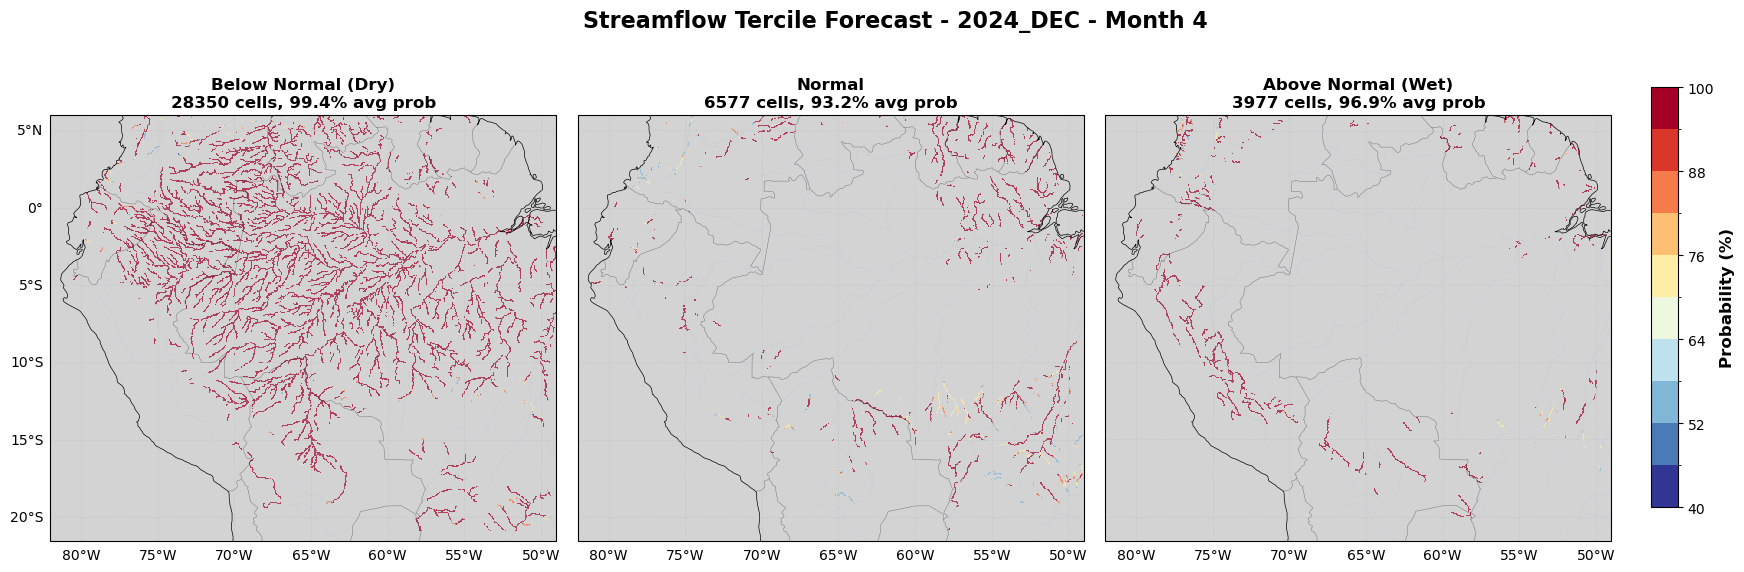

In [ ]:
# #Uncomment to create multi-category visualization:

# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from matplotlib.colors import BoundaryNorm

# # Define colormap for probabilities
# vmin, vmax = 40, 100  # Min tercile probability to max
# n_colors = 10
# cmap = plt.get_cmap('RdYlBu_r', n_colors) # Red=high prob, Blue=low prob
# bounds = np.linspace(vmin, vmax, n_colors+1)
# norm = BoundaryNorm(boundaries=bounds, ncolors=n_colors)

# # Create figure with 3 subplots (one per category)
# fig, axs = plt.subplots(
#     1, 3,
#     subplot_kw={'projection': ccrs.PlateCarree()},
#     figsize=(18, 6)
# )

# # Amazon basin extent
# lis_output_bounds = [-82, -49, -21, 6]  # [min_lon, max_lon, min_lat, max_lat]

# category_titles = {
#     'cat_0': 'Below Normal (Dry)',
#     'cat_1': 'Normal',
#     'cat_2': 'Above Normal (Wet)'
# }

# # Plot each category
# for idx, (cat_key, ax) in enumerate(zip(['cat_0', 'cat_1', 'cat_2'], axs)):
#     gdf = fcst_gdf[np.datetime64('2024-12-31T00:00:00.000000000')][cat_key]
    
#     # Set map extent and features
#     ax.set_extent(lis_output_bounds)
#     ax.coastlines(linewidth=0.5)
#     ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
#     ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.3)
#     ax.set_facecolor('lightgrey')
    
#     # Plot river network if data exists
#     if len(gdf) > 0:
#         gdf.plot(
#             column='probability',
#             ax=ax,
#             cmap=cmap,
#             norm=norm,
#             linewidth=0,
#             alpha=0.7,
#             legend=False
#         )
#         n_cells = len(gdf)
#         mean_prob = gdf['probability'].mean()
#         ax.set_title(f"{category_titles[cat_key]}\n{n_cells} cells, {mean_prob:.1f}% avg prob", 
#                      fontsize=12, fontweight='bold')
#     else:
#         ax.set_title(f"{category_titles[cat_key]}\nNo data", fontsize=12)
    
#     # Add gridlines
#     gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                       linewidth=0.5, alpha=0.3, linestyle='--')
#     gl.top_labels = False
#     gl.right_labels = False
#     if idx > 0:  # Only show y-labels on leftmost plot
#         gl.left_labels = False

# # Add colorbar
# from matplotlib import colorbar
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
# cbar = colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical')
# cbar.set_label('Probability (%)', fontsize=12, fontweight='bold')

# # Main title
# fig.suptitle(f'Streamflow Tercile Forecast - {initialization_date.upper()} - Month {time_index+1}',
#              fontsize=16, fontweight='bold', y=0.98)

# plt.tight_layout(rect=[0, 0, 0.91, 0.96])
# plt.savefig(output_dir / f'streamflow_tercile_categories_{initialization_date}_month{time_index+1}.png',
#             dpi=300) #, bbox_inches='tight')
# plt.show()